In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["text.usetex"] = True

import ipywidgets as widgets
from IPython.display import display

In [2]:
def mono_w(k, kappa = 1, m = 1, a = 1):
    """
    Returns the frequency of normal modes of the 
    harmonic 1D monoatomic chain as a function of their
    wavevector. 
    
    k :    Normal mode wavevector
    kappa: Spring constant defining force between neighboring atoms
    m:     Atomic mass
    a:     Lattice spacing
    """
    
    return 2*np.sqrt(kappa/m)*np.abs(np.sin(k*a/2))

In [3]:
def displacement(n, k, t, A=1, a=1):
    """
    Returns the displacement from equilibrium of the n-th 
    atom at time t for a system in the k-th phonon mode.
    
    """
    
    omega = mono_w(k)
    dx_n = a*np.exp(1j*omega*t-1j*k*n*a)
    return np.real(dx_n)

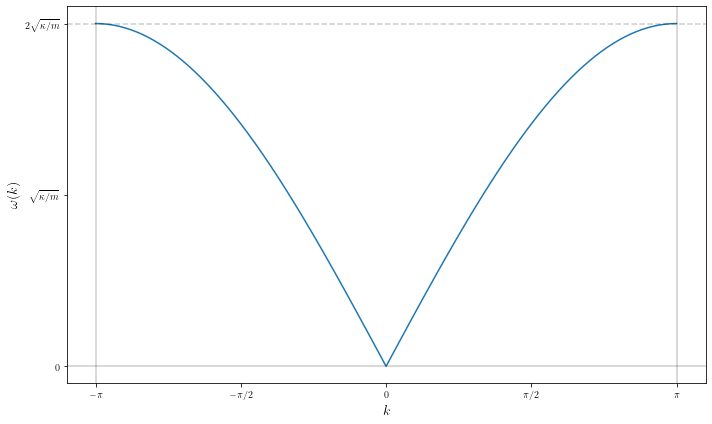

In [9]:
kgrid = np.linspace(-np.pi, np.pi, 101)

plt.figure(figsize = (10,6))

plt.plot(kgrid, mono_w(kgrid))

fs = 14
plt.xlabel('$k$', fontsize=fs)
plt.ylabel('$\omega(k)$', fontsize=fs)

plt.axhline(0, color = 'k', alpha = 0.2)
plt.axhline(2, color = 'k', alpha = 0.2, linestyle = '--')

plt.axvline(-np.pi, color = 'k', alpha = 0.2)
#plt.axvline(0, color = 'k', alpha = 0.2)
plt.axvline(np.pi, color = 'k', alpha = 0.2)

plt.xticks([-np.pi, -np.pi/2, 0, np.pi/2, np.pi], ['$-\pi$', '$-\pi/2$', '$0$', '$\pi/2$', '$\pi$'])
plt.yticks([0,1, 2], ['$0$','$\sqrt{\kappa/m}$', '$2\sqrt{\kappa/m}$'])

plt.tight_layout()

plt.show()

FloatSlider(value=0.0, description='$k/a$', max=3.141592653589793, min=-3.141592653589793, step=0.523598775598…

FloatSlider(value=0.0, description='$t$', max=50.0)

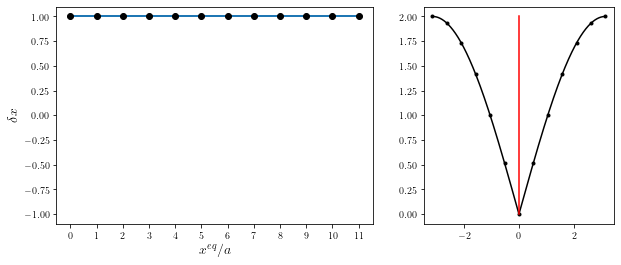

In [5]:
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(10, 4), width_ratios = [5, 3])

N = 12 # Number of atoms
nvals = np.arange(N)
ndense = np.linspace(nvals[0], nvals[-1], 1001)
kvals = 2*np.pi/N*np.array([i for i in range(-N//2, N//2+1)]) #Include redundant mode at right BZ boundary
kdense = np.linspace(-np.pi, np.pi, 1001)
k = kvals[N//2]
t = 0 

ax1.plot(kvals, mono_w(kvals), 'k.')
ax1.plot(kdense, mono_w(kdense), 'k')

y_discrete = displacement(nvals, k, t)
y_dense = displacement(ndense, k, t)

wave, = ax0.plot(ndense, y_dense, lw=2)
atoms,  = ax0.plot(nvals, y_discrete, 'ko')
bar, = ax1.plot([k, k], [0, 2], 'r')

fs=14
ax0.set_xticks(nvals)
ax0.set_xlabel('$x^{eq}/a$', fontsize = fs)
ax0.set_ylabel('$\delta x$', fontsize = fs)
ax0.set_ylim(-1.1, 1.1)

# Create widgets
kvec = widgets.FloatSlider(
    value=kvals[N//2], min=-np.pi, max=np.pi, step=2*np.pi/len(nvals),
    description="$k/a$"
)

time = widgets.FloatSlider(
    value=0, min=0, max=50, step=0.1,
    description="$t$"
)

def update(change=None):
    t = time.value
    k = kvec.value
    
    y_discrete = displacement(nvals, k, t)
    y_dense = displacement(ndense, k, t)

    # Only change the data
    wave.set_ydata(y_dense)
    atoms.set_ydata(y_discrete)
    bar.set_xdata([k, k])

    # Redraw the existing figure
    fig.canvas.draw_idle()

kvec.observe(update, names="value")
time.observe(update, names="value")

display(kvec, time, fig.canvas)

<IPython.core.display.Javascript object>


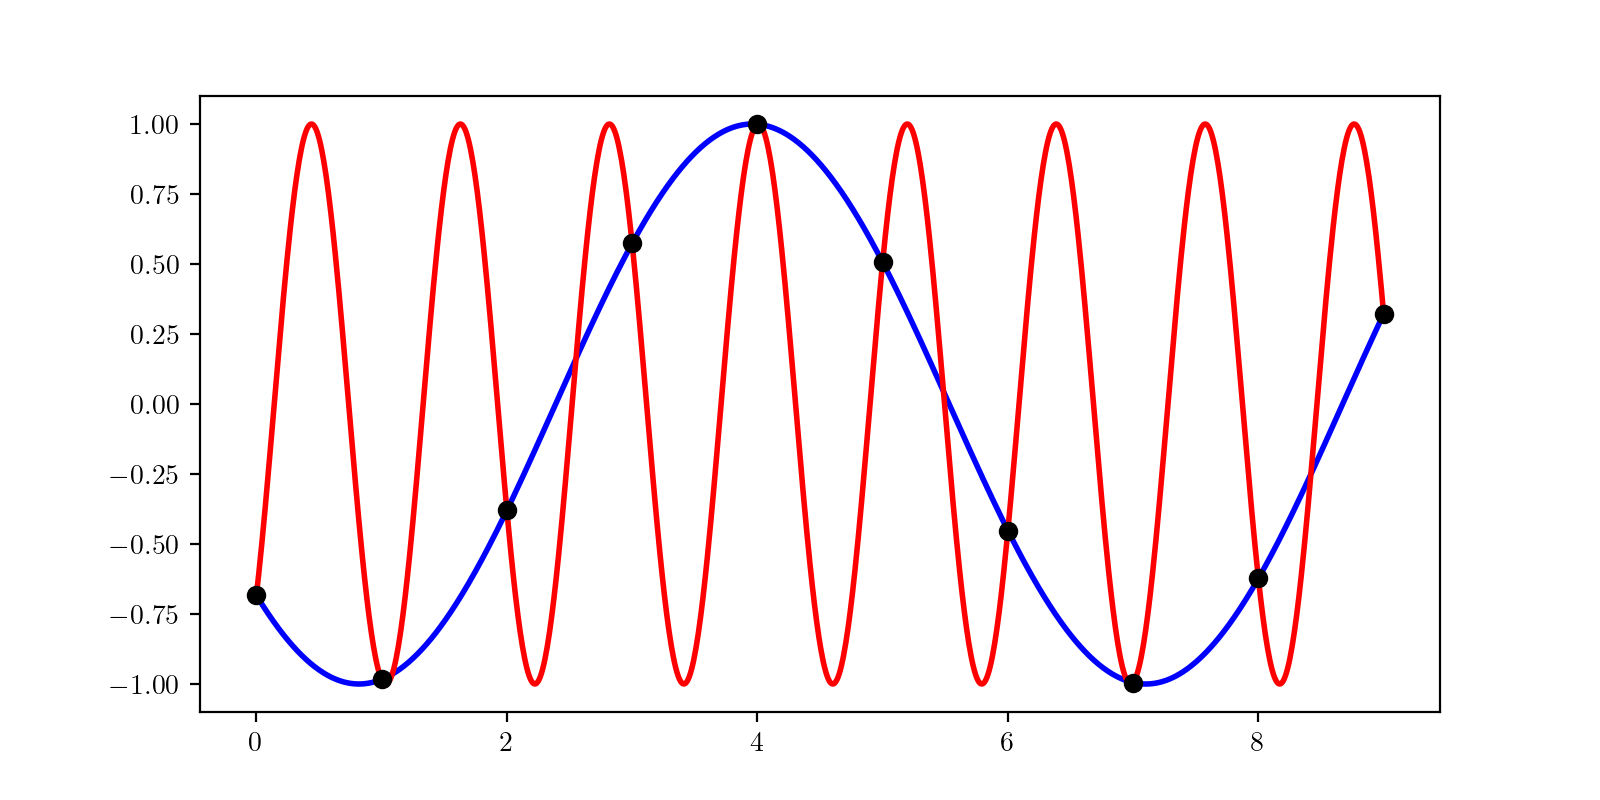

FloatSlider(value=1.0, description='$k/a$', max=3.141592653589793, min=-3.141592653589793, step=0.628318530717…

FloatSlider(value=0.0, description='$t$', max=50.0)

In [81]:
fig, ax = plt.subplots(figsize=(8, 4))

N = 10 # Number of atoms
nvals = np.arange(N)
ndense = np.linspace(nvals[0], nvals[-1], 1001)
kvals = np.linspace(-np.pi, np.pi, )
k = 1
t = 0 

y_discrete = displacement(nvals, k, t)
y1 = displacement(ndense, k, t)
y2 = displacement(ndense, k-2*np.pi, t)

wave1, = ax.plot(ndense, y1, lw=2, color='b')
wave2, = ax.plot(ndense, y2, lw=2, color = 'r')
atoms,  = ax.plot(nvals, y_discrete, 'ko')

#ax.set_xlim(x.min(), x.max())
#ax.set_ylim(-3, 3)
#ax.set_xlabel(r"$x$")
#ax.set_ylabel(r"$y$")
#ax.grid(alpha=0.3)

# Create widgets
kvec = widgets.FloatSlider(
    value=1, min=-np.pi, max=np.pi, step=2*np.pi/len(nvals),
    description="$k/a$"
)

time = widgets.FloatSlider(
    value=0, min=0, max=50, step=0.1,
    description="$t$"
)

def update(change=None):
    t = time.value
    k = kvec.value
    
    y_discrete = displacement(nvals, k, t)
    y1 = displacement(ndense, k, t)
    y2 = displacement(ndense, k-2*np.pi, t)

    # Only change the data
    wave1.set_ydata(y1)
    wave2.set_ydata(y2)
    atoms.set_ydata(y_discrete)

    # Redraw the existing figure
    fig.canvas.draw_idle()

kvec.observe(update, names="value")
time.observe(update, names="value")

display(kvec, time, fig.canvas)